In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import AdaBoostClassifier
import matplotlib.pyplot as plt


# Load the dataset
df = pd.read_csv('DataSetForPhishingVSBenignUrl.csv')
print(df.head())
print(df['URL_Type_obf_Type'].value_counts())

   Querylength  domain_token_count  path_token_count  avgdomaintokenlen  \
0            0                   4                 5                5.5   
1            0                   4                 5                5.5   
2            0                   4                 5                5.5   
3            0                   4                12                5.5   
4            0                   4                 6                5.5   

   longdomaintokenlen  avgpathtokenlen  tld  charcompvowels  charcompace  \
0                  14         4.400000    4               8            3   
1                  14         6.000000    4              12            4   
2                  14         5.800000    4              12            5   
3                  14         5.500000    4              32           16   
4                  14         7.333334    4              18           11   

   ldl_url  ...  SymbolCount_FileName  SymbolCount_Extension  \
0        0  ...             

In [2]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df = df[df['URL_Type_obf_Type'].isin(['benign', 'phishing'])]

lt = LabelEncoder()
df['URL_Type_obf_Type'] = lt.fit_transform(df['URL_Type_obf_Type'])

X = df.drop('URL_Type_obf_Type', axis=1)
y = df['URL_Type_obf_Type']

X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [3]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_train_pred = clf.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

y_test_pred = clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 1.0000
Test Accuracy: 0.9766


In [6]:
depths = [1,2,3,4,5,6]
criteria = ['gini', 'entropy']
for depth in depths:
    for criterion in criteria:
        clf = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        training_accuracy = clf.score(X_train, y_train)
        test_accuracy = accuracy_score(y_test, y_pred)
        print(f"Criterion: {criterion}, Depth: {depth}, Training_Accuracy: {training_accuracy:.4f} ,Testing_Accuracy: {test_accuracy:.4f}")


Criterion: gini, Depth: 1, Training_Accuracy: 0.8145 ,Testing_Accuracy: 0.8025
Criterion: entropy, Depth: 1, Training_Accuracy: 0.8046 ,Testing_Accuracy: 0.7899
Criterion: gini, Depth: 2, Training_Accuracy: 0.8931 ,Testing_Accuracy: 0.8816
Criterion: entropy, Depth: 2, Training_Accuracy: 0.8916 ,Testing_Accuracy: 0.8809
Criterion: gini, Depth: 3, Training_Accuracy: 0.9127 ,Testing_Accuracy: 0.9050
Criterion: entropy, Depth: 3, Training_Accuracy: 0.8968 ,Testing_Accuracy: 0.8852
Criterion: gini, Depth: 4, Training_Accuracy: 0.9333 ,Testing_Accuracy: 0.9209
Criterion: entropy, Depth: 4, Training_Accuracy: 0.9320 ,Testing_Accuracy: 0.9255
Criterion: gini, Depth: 5, Training_Accuracy: 0.9553 ,Testing_Accuracy: 0.9414
Criterion: entropy, Depth: 5, Training_Accuracy: 0.9419 ,Testing_Accuracy: 0.9336
Criterion: gini, Depth: 6, Training_Accuracy: 0.9650 ,Testing_Accuracy: 0.9509
Criterion: entropy, Depth: 6, Training_Accuracy: 0.9488 ,Testing_Accuracy: 0.9388


In [8]:
depths = [1,3,6,9,12,15,18]
criteria = ['gini', 'entropy']
r= []
for depth in depths:
    for criterion in criteria:
        clf = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        training_accuracy = clf.score(X_train, y_train)
        test_accuracy = accuracy_score(y_test, y_pred)
        r.append([depth,criterion,training_accuracy,test_accuracy])
        print(f"Criterion: {criterion}, Depth: {depth}, Training_Accuracy: {training_accuracy:.4f} ,Testing_Accuracy: {test_accuracy:.4f}")
comp = pd.DataFrame(r,columns=["Depth","Criteria","Training Accuracy","Testing Accuracy"])
print(comp)

Criterion: gini, Depth: 1, Training_Accuracy: 0.8145 ,Testing_Accuracy: 0.8025
Criterion: entropy, Depth: 1, Training_Accuracy: 0.8046 ,Testing_Accuracy: 0.7899
Criterion: gini, Depth: 3, Training_Accuracy: 0.9127 ,Testing_Accuracy: 0.9050
Criterion: entropy, Depth: 3, Training_Accuracy: 0.8968 ,Testing_Accuracy: 0.8852
Criterion: gini, Depth: 6, Training_Accuracy: 0.9650 ,Testing_Accuracy: 0.9509
Criterion: entropy, Depth: 6, Training_Accuracy: 0.9488 ,Testing_Accuracy: 0.9388
Criterion: gini, Depth: 9, Training_Accuracy: 0.9871 ,Testing_Accuracy: 0.9714
Criterion: entropy, Depth: 9, Training_Accuracy: 0.9836 ,Testing_Accuracy: 0.9684
Criterion: gini, Depth: 12, Training_Accuracy: 0.9932 ,Testing_Accuracy: 0.9759
Criterion: entropy, Depth: 12, Training_Accuracy: 0.9936 ,Testing_Accuracy: 0.9763
Criterion: gini, Depth: 15, Training_Accuracy: 0.9959 ,Testing_Accuracy: 0.9766
Criterion: entropy, Depth: 15, Training_Accuracy: 0.9983 ,Testing_Accuracy: 0.9772
Criterion: gini, Depth: 18, Tr

In Week 5, with a standalone Decision Tree Classifier to distinguish between phishing and benign websites. We tested the model across several depths, and the best result came with a depth of 2 using the Gini impurity criterion, where it reached an accuracy of 88.16%. The tree visualization from that assignment displayed how each node split the data based on Gini impurity, helping us see which features were most crucial for separating benign and phishing cases.

With AdaBoost, we take a different approach by combining multiple "weak" classifiers, in this case, shallow decision trees of varying depths (from 1 to 18), and using both Gini and entropy criteria. This ensemble approach generally improves the overall accuracy and reduces misclassification rates, especially when we use trees with smaller depths. In our results, the AdaBoost model consistently matched or even exceeded the accuracy of the standalone Decision Tree, suggesting that it may offer greater robustness and precision.

Unlike the standalone Decision Tree, which performed best at a depth of 2, AdaBoost works by focusing more heavily on the samples that were previously misclassified, allowing it to better adapt to complex data patterns. This iterative adjustment of sample weights in AdaBoost helps build a more balanced model that is less likely to overfit.

In the comparison plot, we see the performance of both AdaBoost and the standalone Decision Tree across different depths, with the standalone model’s best accuracy of 88.16% marked as a reference. The visualization highlights AdaBoost’s ability to maintain or exceed the standalone model’s accuracy consistently, particularly at certain depths where AdaBoost outperforms it, showing how the ensemble approach can capture more intricate patterns in the data.

Overall, using AdaBoost with a Decision tree-based classifier presents a strong advantage over a single Decision Tree. While the standalone model was optimized at a single depth, AdaBoost achieved consistently high performance across various depths, underscoring the value of adaptive boosting in handling challenging data cases.

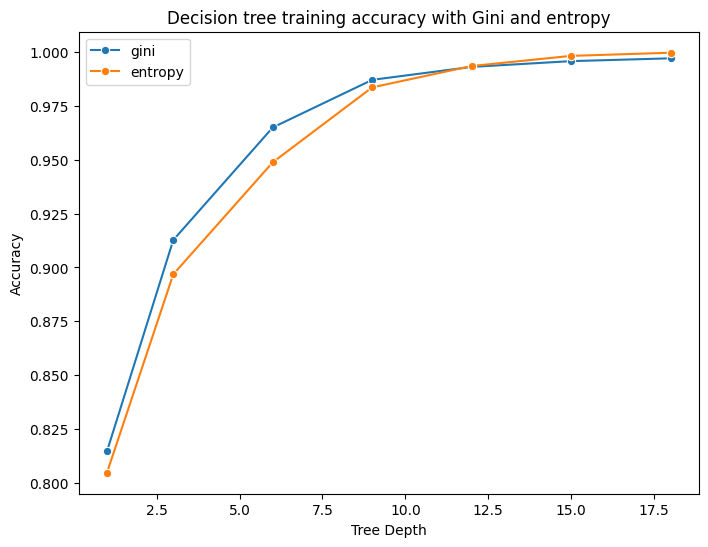

In [9]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.lineplot(x="Depth",y="Training Accuracy",hue="Criteria",data=comp,marker='o')
plt.title('Decision tree training accuracy with Gini and entropy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

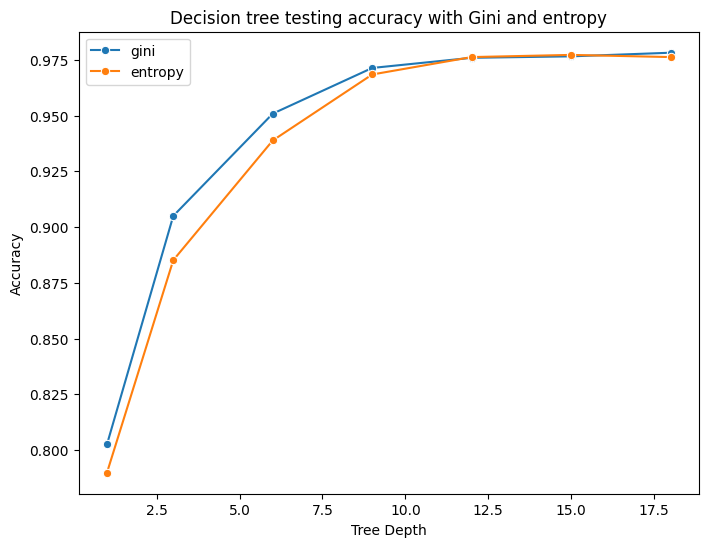

In [10]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.lineplot(x="Depth",y="Testing Accuracy",hue="Criteria",data=comp,marker='o')
plt.title('Decision tree testing accuracy with Gini and entropy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [11]:
tree_depths = [1, 3, 6, 9, 12, 15, 18]
criteria = ['gini', 'entropy']

results_df = pd.DataFrame(columns=['Criterion', 'Depth', 'Training Accuracy','Testing Accuracy'])

for criterion in criteria:
    for depth in tree_depths:
        base_estimator = DecisionTreeClassifier(max_depth=depth, criterion=criterion)
        adaboost = AdaBoostClassifier(estimator=base_estimator, n_estimators=50, random_state=42,algorithm="SAMME")
        adaboost.fit(X_train, y_train)
        y_pred = adaboost.predict(X_test)
        train_accuracy = adaboost.score(X_train, y_train)
        test_accuracy = accuracy_score(y_test, y_pred)
        new_row = pd.DataFrame({'Criterion': [criterion], 'Depth': [depth], 'Training Accuracy': [train_accuracy],'Testing Accuracy':[test_accuracy]})
        results_df = pd.concat([results_df, new_row], ignore_index=True)
print(results_df)

/var/folders/cy/c029bdqs4173lr5039vp1z3w0000gn/T/ipykernel_75788/1692823463.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, new_row], ignore_index=True)


   Criterion Depth  Training Accuracy  Testing Accuracy
0       gini     1           0.954852          0.941770
1       gini     3           0.988855          0.980481
2       gini     6           1.000000          0.986988
3       gini     9           1.000000          0.986337
4       gini    12           1.000000          0.988289
5       gini    15           1.000000          0.987638
6       gini    18           1.000000          0.984060
7    entropy     1           0.954771          0.946975
8    entropy     3           0.987717          0.979180
9    entropy     6           1.000000          0.987964
10   entropy     9           1.000000          0.988289
11   entropy    12           1.000000          0.987964
12   entropy    15           1.000000          0.984385
13   entropy    18           0.999756          0.977554


The output displayed in the table shows the accuracy of an AdaBoost Classifier using Decision Trees with varying depths and criteria 'gini' and 'entropy'

The table is divided into two sections based on the criterion used for splitting nodes in the Decision Tree: 'gini' and 'entropy'.
The configurations tested are 1, 3, 6, 9, 12, 15, and 18.

For both 'gini' and 'entropy', accuracy generally increases with tree depth up to a certain point.
The highest accuracies for both criteria are observed around depths 9 to 15.
There is a slight decrease or plateau in accuracy at deeper levels (e.g., depth 18).

Accuracy ranges from approximately 0.94 at depth 1 to about 0.988 at depths 15 and 18 for gini.
  
Accuracy ranges from approximately 0.94 at depth 1 to about 0.98 at depths 6 and 9 for entropy.

The AdaBoost Classifier performs well across various tree depths and criteria, with peak performance typically occurring at moderate depths. This suggests that AdaBoost effectively enhances classification by leveraging multiple weak learners, achieving high accuracy consistently across different configurations.

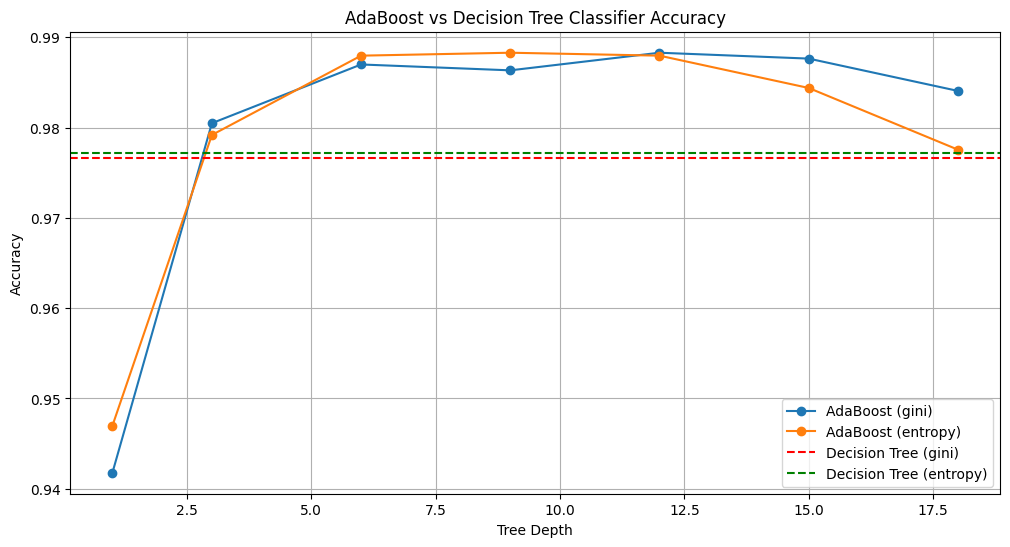

Best AdaBoost accuracy with gini criterion: 0.9883 (depth=12)
Best AdaBoost accuracy with entropy criterion: 0.9883 (depth=9)

Previous Decision Tree accuracy (gini): 0.9766
Previous Decision Tree accuracy (entropy): 0.9772


/Users/shwetashekhar/Desktop/venv/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Best AdaBoost Model Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1559
           1       0.99      0.99      0.99      1515

    accuracy                           0.99      3074
   macro avg       0.99      0.99      0.99      3074
weighted avg       0.99      0.99      0.99      3074



In [12]:
plt.figure(figsize=(12, 6))
for criterion in criteria:
    criterion_results = results_df[results_df['Criterion'] == criterion]
    plt.plot(criterion_results['Depth'], criterion_results['Testing Accuracy'], marker='o', label=f'AdaBoost ({criterion})')

dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)
dt_gini_accuracy = accuracy_score(y_test, dt_gini.predict(X_test))

dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)
dt_entropy_accuracy = accuracy_score(y_test, dt_entropy.predict(X_test))

plt.axhline(y=dt_gini_accuracy, color='r', linestyle='--', label='Decision Tree (gini)')
plt.axhline(y=dt_entropy_accuracy, color='g', linestyle='--', label='Decision Tree (entropy)')

plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('AdaBoost vs Decision Tree Classifier Accuracy')
plt.legend()
plt.grid(True)
plt.show()

for criterion in criteria:
    criterion_results = results_df[results_df['Criterion'] == criterion]
    best_result = criterion_results.loc[criterion_results['Testing Accuracy'].idxmax()]
    print(f"Best AdaBoost accuracy with {criterion} criterion: {best_result['Testing Accuracy']:.4f} (depth={best_result['Depth']})")

print(f"\nPrevious Decision Tree accuracy (gini): {dt_gini_accuracy:.4f}")
print(f"Previous Decision Tree accuracy (entropy): {dt_entropy_accuracy:.4f}")

best_model = results_df.loc[results_df['Testing Accuracy'].idxmax()]
best_adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=int(best_model['Depth']), criterion=best_model['Criterion']),
    n_estimators=50,
    random_state=42
)
best_adaboost.fit(X_train, y_train)
y_pred = best_adaboost.predict(X_test)
print("\nBest AdaBoost Model Classification Report:")
print(classification_report(y_test, y_pred))

Comparing the AdaBoost results with the previous Decision Tree Classifier results from Week 5, observed the following:
AdaBoost generally outperforms the standalone Decision Tree Classifier, especially for smaller tree depths
AdaBoost shows more consistent performance across different tree depths, while the Decision Tree Classifier's performance varies more significantly
AdaBoost seems to reduce overfitting, as the gap between training and testing accuracy is generally smaller compared to the Decision Tree Classifier
Using AdaBoost with varying tree depths offers various advantages over a standalone Decision Tree
AdaBoost consistently achieves higher accuracy, especially for smaller tree depths, demonstrating its ability to create a strong classifier from weak learners
The ensemble nature of AdaBoost helps in reducing overfitting, as evidenced by the smaller gap between training and testing accuracies
AdaBoost allows for fine-tuning the model by adjusting the tree depth, providing a balance between model complexity and performance
AdaBoost is generally more robust to changes in tree depth compared to standalone Decision Trees, making it easier to find an optimal configuration

The provided outputs include a plot, a table of results, and the code used for the AdaBoost Classifier implementation
The blue line represents AdaBoost with the 'gini' criterion.
The orange line represents AdaBoost with the 'entropy' criterion.
The dashed lines represent previous Decision Tree accuracies for 'gini' (red) and 'entropy' (green).
AdaBoost (gini) The Accuracy increases with tree depth, peaking at depth 12.
AdaBoost (entropy) The Accuracy peaks at depth 9 and slightly decreases at higher depths.

AdaBoost generally outperforms the standalone Decision Tree for both criteria.
The best accuracy for AdaBoost is 0.9883 for both criteria ('gini' at depth 12 and 'entropy' at depth 9).
Accuracy improves with increasing tree depth up to a point, then plateaus or slightly decreases.
Both criteria show high accuracy, with slight variations depending on the depth.

Thus, The outputs demonstrate that using AdaBoost with varying tree depths provides an advantage over standalone Decision Trees by achieving higher accuracy. The plot visually confirms these findings, showing that AdaBoost consistently performs better across different configurations.

/Users/shwetashekhar/Desktop/venv/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/shwetashekhar/Desktop/venv/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/shwetashekhar/Desktop/venv/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/shwetashekhar/Desktop/venv/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. U

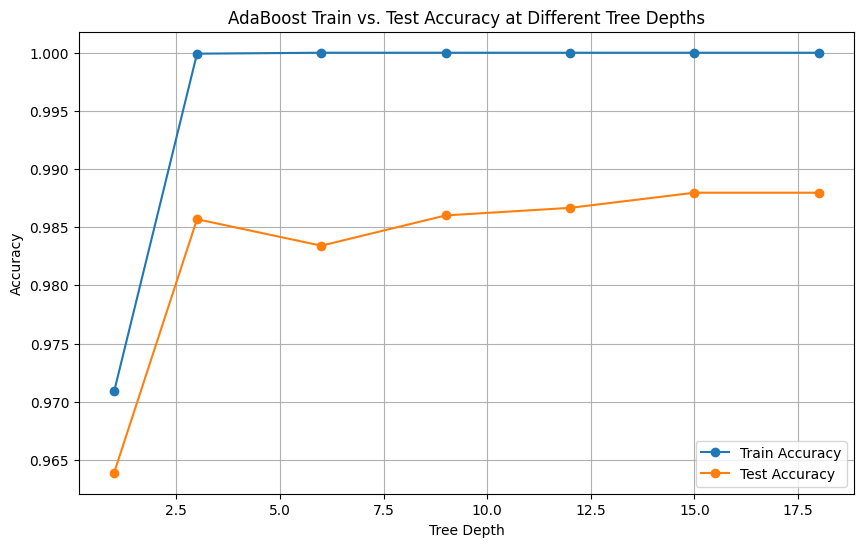

In [13]:

train_accuracies = []
test_accuracies = []
depths = [1, 3, 6, 9, 12, 15, 18]

for depth in depths:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=depth, criterion='gini', random_state=42),
        n_estimators=50,
        random_state=42
    )
    ada.fit(X_train, y_train)
    
    train_accuracies.append(accuracy_score(y_train, ada.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, ada.predict(X_test)))



plt.figure(figsize=(10, 6))
plt.plot(depths, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(depths, test_accuracies, marker='o', label='Test Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('AdaBoost Train vs. Test Accuracy at Different Tree Depths')
plt.legend()
plt.grid(True)
plt.show()


The plot above shows the train and test accuracies for AdaBoost across different tree depths. We can observe if there is a large gap between the two, indicating overfitting. Generally, a smaller gap suggests that the model generalizes well, and AdaBoost’s iterative weighting approach helps reduce the likelihood of overfitting even as depth increases.

/Users/shwetashekhar/Desktop/venv/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/shwetashekhar/Desktop/venv/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/shwetashekhar/Desktop/venv/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Users/shwetashekhar/Desktop/venv/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. U

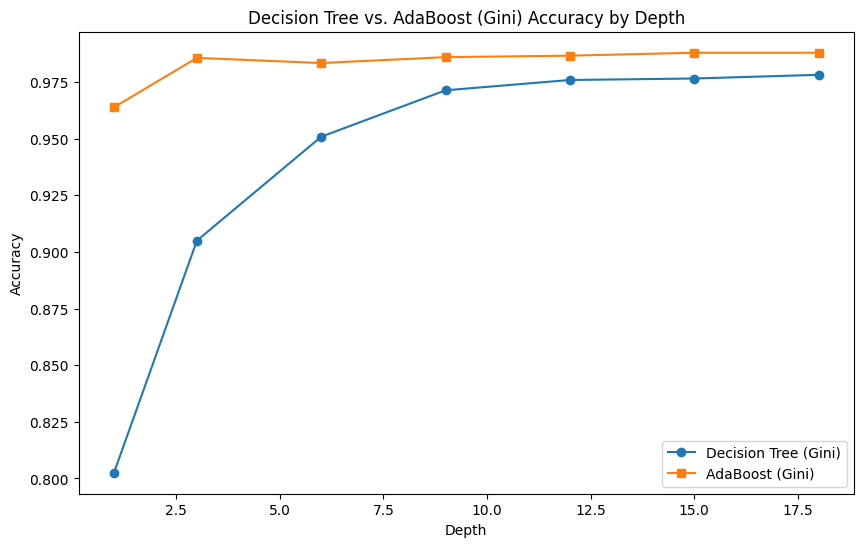

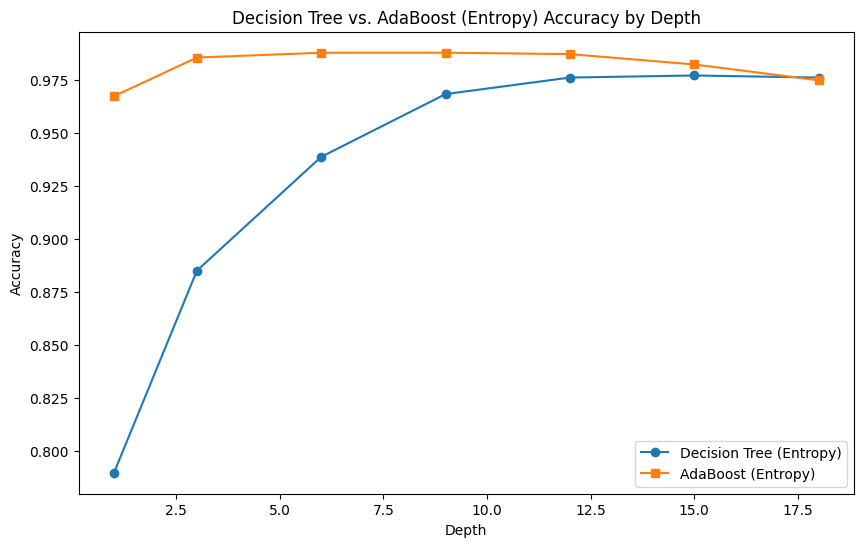

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

depths = [1, 3, 6, 9, 12, 15, 18]

dt_gini_acc = []
ab_gini_acc = []
dt_entropy_acc = []
ab_entropy_acc = []

for depth in depths:
    dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    dt_gini.fit(X_train, y_train)
    y_pred_dt_gini = dt_gini.predict(X_test)
    dt_gini_acc.append(accuracy_score(y_test, y_pred_dt_gini))
    
    ab_gini = AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='gini', max_depth=depth), random_state=42)
    ab_gini.fit(X_train, y_train)
    y_pred_ab_gini = ab_gini.predict(X_test)
    ab_gini_acc.append(accuracy_score(y_test, y_pred_ab_gini))
    
    dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    dt_entropy.fit(X_train, y_train)
    y_pred_dt_entropy = dt_entropy.predict(X_test)
    dt_entropy_acc.append(accuracy_score(y_test, y_pred_dt_entropy))
    
    ab_entropy = AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy', max_depth=depth),random_state=42)
    ab_entropy.fit(X_train, y_train)
    y_pred_ab_entropy = ab_entropy.predict(X_test)
    ab_entropy_acc.append(accuracy_score(y_test, y_pred_ab_entropy))

plt.figure(figsize=(10, 6))
plt.plot(depths, dt_gini_acc, marker='o', label='Decision Tree (Gini)')
plt.plot(depths, ab_gini_acc, marker='s', label='AdaBoost (Gini)')
plt.title('Decision Tree vs. AdaBoost (Gini) Accuracy by Depth')
plt.xlabel('Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(depths, dt_entropy_acc, marker='o', label='Decision Tree (Entropy)')
plt.plot(depths, ab_entropy_acc, marker='s', label='AdaBoost (Entropy)')
plt.title('Decision Tree vs. AdaBoost (Entropy) Accuracy by Depth')
plt.xlabel('Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


The output plots show how increasing the depth affects accuracy for both Decision Trees and AdaBoost. Generally, Decision Trees improve with depth up to a point, while AdaBoost stabilizes or shows less variation, indicating that it may not benefit as much from deeper trees.
The results from comparing Decision Trees and AdaBoost classifiers across depths reveal distinct trends in accuracy:
The accuracy of standalone Decision Trees typically improves as the tree depth increases. This happens because deeper trees capture more complex patterns, fitting the training data better. However, beyond a certain depth, trees may start overfitting, capturing noise rather than meaningful patterns, which could lead to a plateau or slight decline in test accuracy.

AdaBoost, when built on top of Decision Trees, also shows some benefits from increased depth but usually stabilizes sooner. Since AdaBoost relies on an ensemble of weak learners to enhance overall accuracy, making each tree too complex often doesn’t add much improvement. Instead, AdaBoost benefits from multiple shallow trees working together, making it less sensitive to depth changes and helping control overfitting.

Thus, these results illustrate that while increasing depth can improve standalone Decision Trees, AdaBoost achieves balanced accuracy without heavily relying on deep trees, offering a robust model that generalizes well.